#  Gaussian Mixture model Implemantation

In [28]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
from sklearn.mixture import GaussianMixture
from matplotlib.patches import Circle, Ellipse

In [29]:
# ---- Step 1: Generate elliptical, overlapped clusters + noise ----
np.random.seed(42)

mean1 = [0, 0]
mean2 = [4, 5]
mean3 = [8, 0]

cov1 = [[4, 1.5], [1.5, 1]]
cov2 = [[3, -1.2], [-1.2, 2]]
cov3 = [[2, 0.8], [0.8, 3]]

X1 = np.random.multivariate_normal(mean1, cov1, 350)
X2 = np.random.multivariate_normal(mean2, cov2, 350)
X3 = np.random.multivariate_normal(mean3, cov3, 350)

# Add noise points
noise = np.random.uniform(low=-5, high=12, size=(120, 2))
X = np.vstack((X1, X2, X3, noise))



In [31]:

# ---- Step 2: K-means ----
kmeans = KMeans(n_clusters=3, random_state=42)
kmeans_labels = kmeans.fit_predict(X)
kmeans_centers = kmeans.cluster_centers_

# Compute radius as average distance to center
def kmeans_radius(X, labels, centers, cluster_id):
    pts = X[labels == cluster_id]
    if len(pts) == 0:
        return 0
    return np.mean(np.linalg.norm(pts - centers[cluster_id], axis=1))



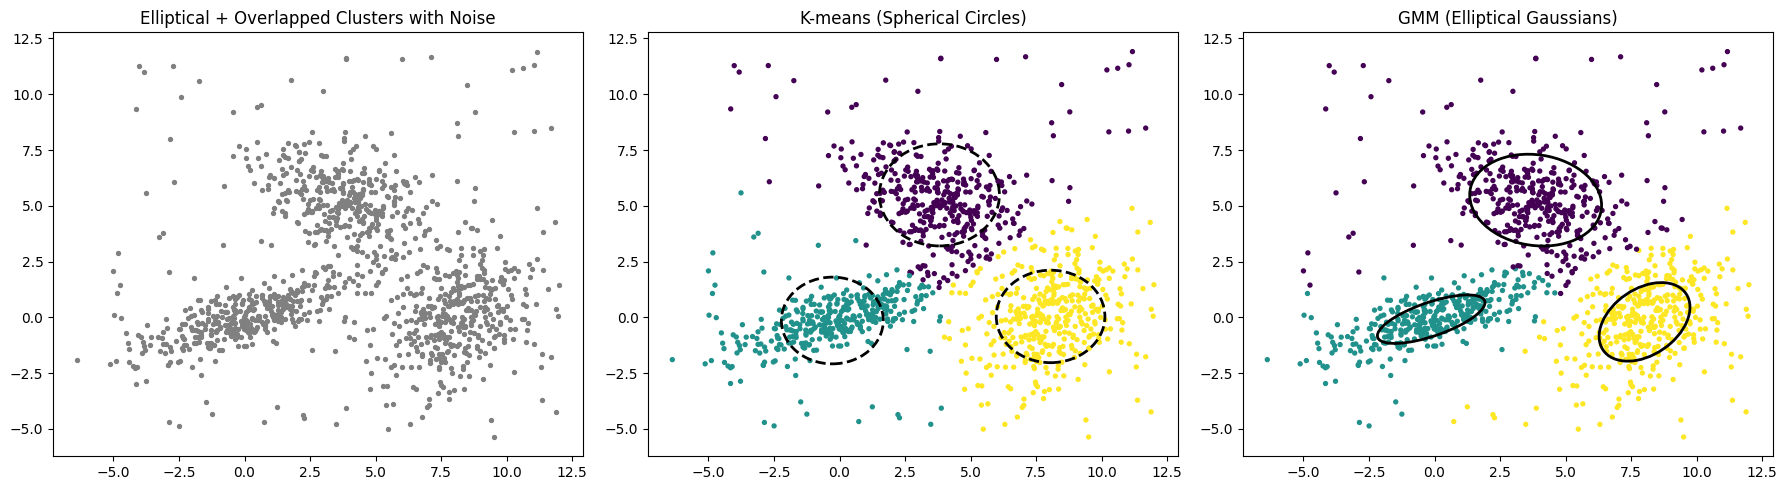

In [32]:


# ---- Step 3: GMM ----
gmm = GaussianMixture(n_components=3, covariance_type='full', random_state=42)
gmm_labels = gmm.fit_predict(X)


# ---- Helper: Draw GMM ellipses ----
def draw_ellipse(mean, cov, ax, color):
    vals, vecs = np.linalg.eigh(cov)

    # Width & height = 2 std deviations
    width, height = 2 * np.sqrt(vals)
    angle = np.degrees(np.arctan2(vecs[1, 0], vecs[0, 0]))

    ellipse = Ellipse(
        xy=mean,
        width=width,
        height=height,
        angle=angle,
        edgecolor=color,
        facecolor='none',
        linewidth=2
    )
    ax.add_patch(ellipse)


# ---- Helper: Draw K-means circles ----
def draw_circle(center, radius, ax, color):
    circle = Circle(
        xy=center,
        radius=radius,
        edgecolor=color,
        facecolor='none',
        linewidth=2,
        linestyle='--'
    )
    ax.add_patch(circle)


# ---- Step 4: Plotting ----
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Raw data
axes[0].scatter(X[:, 0], X[:, 1], s=8, color='gray')
axes[0].set_title("Elliptical + Overlapped Clusters with Noise")

# K-means plot
axes[1].scatter(X[:, 0], X[:, 1], c=kmeans_labels, cmap="viridis", s=8)
axes[1].set_title("K-means (Spherical Circles)")

# Draw circles for each K-means cluster
for i in range(3):
    r = kmeans_radius(X, kmeans_labels, kmeans_centers, i)
    draw_circle(kmeans_centers[i], r, axes[1], 'black')

# GMM plot
axes[2].scatter(X[:, 0], X[:, 1], c=gmm_labels, cmap="viridis", s=8)
axes[2].set_title("GMM (Elliptical Gaussians)")

# Draw ellipses for GMM clusters
for i in range(3):
    draw_ellipse(gmm.means_[i], gmm.covariances_[i], axes[2], 'black')

plt.tight_layout()
plt.show()


# 1. GMM for Image Segmentation 

GMM is widely used in computer vision for segmenting images based on color distribution.

In [6]:
# pip install opencv-python

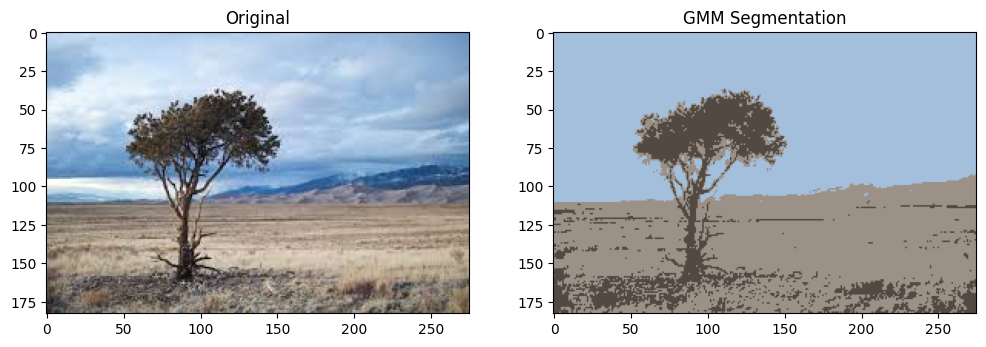

In [36]:
import cv2
import numpy as np
from sklearn.mixture import GaussianMixture
import matplotlib.pyplot as plt

# Read an image
img = cv2.imread("D:\\SIStec\\MLDL-2025\\Clustering\\GMM\\sample_img.jfif")        # <-- Use any image file
img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

# Reshape to a list of pixels
pixels = img.reshape(-1, 3)

# Fit GMM
gmm = GaussianMixture(n_components=3, covariance_type='tied', random_state=42)
gmm_labels = gmm.fit_predict(pixels)

# Recreate segmented image
segmented_img = gmm.means_[gmm_labels].reshape(img.shape).astype(np.uint8)

# Plot
plt.figure(figsize=(12,5))
plt.subplot(1,2,1); plt.imshow(img); plt.title("Original")
plt.subplot(1,2,2); plt.imshow(segmented_img); plt.title("GMM Segmentation")
plt.show()


# 2. GMM for Anomaly Detection in Finance (Credit Card / Transaction Data)

GMM models normal transaction patterns, and low-likelihood points become anomalies.

Dataset created. Shape: (1900, 3)
        amount    time_gap  merchant_freq  anomaly
0  1698.685661   20.409688       2.997681        0
1  1444.694280   36.345915       6.270474        0
2  1759.075415  148.080472       4.792638        1
3  2109.211943    4.229255       5.926304        0
4  1406.338650    9.636401       5.529569        0


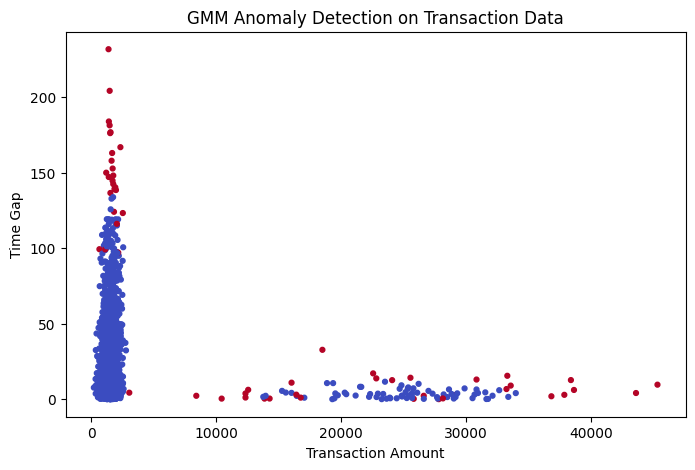

In [37]:
import numpy as np
import pandas as pd
from sklearn.mixture import GaussianMixture
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt

np.random.seed(42)

# ---- Step 1: Create synthetic real-like transaction data ----
n_normal = 1800
n_fraud = 100

# Normal transactions
normal_amount = np.random.normal(1500, 400, n_normal).clip(50, 5000)
normal_timegap = np.random.exponential(30, n_normal)
normal_freq = np.random.normal(5, 1.2, n_normal)

# Fraud transactions
fraud_amount = np.random.normal(25000, 8000, n_fraud).clip(8000, 50000)
fraud_timegap = np.random.exponential(5, n_fraud)     # frequent transactions
fraud_freq = np.random.normal(20, 4, n_fraud)         # intense merchant behavior

# Combine dataset
amount = np.concatenate([normal_amount, fraud_amount])
timegap = np.concatenate([normal_timegap, fraud_timegap])
freq = np.concatenate([normal_freq, fraud_freq])

df = pd.DataFrame({
    "amount": amount,
    "time_gap": timegap,
    "merchant_freq": freq
})

print("Dataset created. Shape:", df.shape)

# ---- Step 2: Scale features ----
X = df.values
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# ---- Step 3: Fit GMM ----
gmm = GaussianMixture(n_components=2, covariance_type='full', random_state=42)
gmm.fit(X_scaled)

# Likelihood score
log_likelihood = gmm.score_samples(X_scaled)

# Threshold = lowest 3% of likelihoods → anomaly flag
threshold = np.percentile(log_likelihood, 3)
df["anomaly"] = (log_likelihood < threshold).astype(int)

print(df.head())

# ---- Step 4: Visualize result ----
plt.figure(figsize=(8,5))
plt.scatter(df['amount'], df['time_gap'], 
            c=df['anomaly'], cmap="coolwarm", s=12)
plt.xlabel("Transaction Amount")
plt.ylabel("Time Gap")
plt.title("GMM Anomaly Detection on Transaction Data")
plt.show()


🎯 What You Will See

GMM will classify:

Normal transactions → low amount, moderate frequency
Fraudulent transactions →

High amount (20k–50k)

Unusually small time gaps

Very high transaction frequency

The red points (= anomalies) will appear in the high-risk region.

# 5. GMM for Outlier Removal in Machine Learning (Preprocessing)

GMM helps remove noisy data points that do not fit the global distribution.

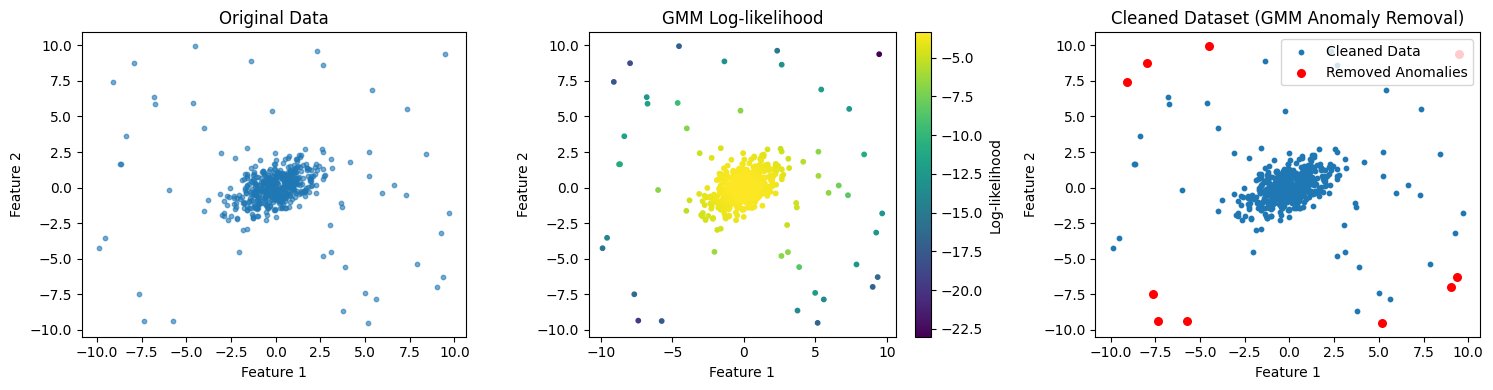

Original: (500, 2)
Cleaned : (490, 2)
Removed anomalies: (10, 2)


In [14]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.mixture import GaussianMixture

# -------------------------------------------------------------
# Generate sample dataset (use your own X if already available)
# -------------------------------------------------------------
np.random.seed(42)

# Main cluster (good samples)
X1 = np.random.multivariate_normal(
    mean=[0, 0],
    cov=[[1.5, 0.6],[0.6, 1.0]],
    size=450
)

# Noise / anomalies
X2 = np.random.uniform(low=-10, high=10, size=(50, 2))

# Combine
X = np.vstack([X1, X2])

# -------------------------------------------------------------
# Fit GMM
# -------------------------------------------------------------
gmm = GaussianMixture(n_components=1, covariance_type='full', random_state=42)
gmm.fit(X)

# Compute log-likelihood scores
log_probs = gmm.score_samples(X)

# Threshold for anomaly removal (lowest 2%)
threshold = np.percentile(log_probs, 2)

# Cleaned dataset
clean_X = X[log_probs > threshold]
anomalies = X[log_probs <= threshold]

# -------------------------------------------------------------
# Visualization
# -------------------------------------------------------------
plt.figure(figsize=(15, 4))

# 1. Original data
plt.subplot(1, 3, 1)
plt.scatter(X[:, 0], X[:, 1], s=10, alpha=0.6)
plt.title("Original Data")
plt.xlabel("Feature 1")
plt.ylabel("Feature 2")

# 2. Log-likelihood heatmap
plt.subplot(1, 3, 2)
plt.scatter(X[:, 0], X[:, 1], c=log_probs, cmap='viridis', s=10)
plt.colorbar(label="Log-likelihood")
plt.title("GMM Log-likelihood")
plt.xlabel("Feature 1")
plt.ylabel("Feature 2")

# 3. Cleaned data (Anomaly Removed)
plt.subplot(1, 3, 3)
plt.scatter(clean_X[:, 0], clean_X[:, 1], s=10, label="Cleaned Data")
plt.scatter(anomalies[:, 0], anomalies[:, 1], s=30, color="red", label="Removed Anomalies")
plt.title("Cleaned Dataset (GMM Anomaly Removal)")
plt.legend()
plt.xlabel("Feature 1")
plt.ylabel("Feature 2")

plt.tight_layout()
plt.show()

print("Original:", X.shape)
print("Cleaned :", clean_X.shape)
print("Removed anomalies:", anomalies.shape)



# GMM for Speaker Recognition (Audio MFCC Features)
GMM is a classic method for modeling voice characteristics.

In [ ]:
# pip install librosa


  Using cached pycparser-2.23-py3-none-any.whl.metadata (993 bytes)
   ---------------------------------------- 0.0/2.8 MB ? eta -:--:--
   --------------- ------------------------ 1.0/2.8 MB 4.2 MB/s eta 0:00:01
   ---------------------------------- ----- 2.4/2.8 MB 4.8 MB/s eta 0:00:01
   ---------------------------------------- 2.8/2.8 MB 4.4 MB/s  0:00:00
   ---------------------------------------- 0.0/38.1 MB ? eta -:--:--
    --------------------------------------- 0.8/38.1 MB 4.2 MB/s eta 0:00:09
   - -------------------------------------- 1.8/38.1 MB 4.4 MB/s eta 0:00:09
   --- ------------------------------------ 2.9/38.1 MB 4.7 MB/s eta 0:00:08
   ---- ----------------------------------- 3.9/38.1 MB 4.8 MB/s eta 0:00:08
   ----- ---------------------------------- 5.0/38.1 MB 4.9 MB/s eta 0:00:07
   ------ --------------------------------- 6.0/38.1 MB 4.9 MB/s eta 0:00:07
   ------- -------------------------------- 6.8/38.1 MB 4.8 MB/s eta 0:00:07
   ------- ------------------

In [38]:
import librosa
import numpy as np
from sklearn.mixture import GaussianMixture

# Load audio file
y, sr = librosa.load("D:\\SIStec\\MLDL-2025\\Clustering\\GMM\\speach_dataset\\16000_pcm_speeches\\Benjamin_Netanyau\\1.wav")

# Extract MFCC features
mfcc = librosa.feature.mfcc(y=y, sr=sr, n_mfcc=13).T

# Train GMM for speaker identity
gmm = GaussianMixture(n_components=8, covariance_type='diag', random_state=42)
gmm.fit(mfcc)

print("Speaker GMM model trained!")


Speaker GMM model trained!


In [25]:
import librosa
import numpy as np
from sklearn.mixture import GaussianMixture

# ---------------------------------------------------------
# 1. Load audio file
# ---------------------------------------------------------
# librosa.load() reads the audio file into a floating-point waveform.
# y  : audio time-series (amplitude values)
# sr : sample rate (number of samples per second)
y, sr = librosa.load(r"D:\SIStec\MLDL-2025\Clustering\GMM\speach_dataset\16000_pcm_speeches\Benjamin_Netanyau\0.wav")

# ---------------------------------------------------------
# 2. Extract MFCC features
# ---------------------------------------------------------
# MFCC (Mel-frequency cepstral coefficients) are widely used in speech processing.
# They compactly represent the shape of the audio frequency spectrum.
# We extract 13 MFCC features per frame.
mfcc = librosa.feature.mfcc(y=y, sr=sr, n_mfcc=13).T  
# .T is used to make rows = frames, columns = MFCC features

# mfcc shape = (num_frames, 13)
# Example: 400 frames → 400 x 13 matrix

# ---------------------------------------------------------
# 3. Train GMM for Speaker Identity Modeling
# ---------------------------------------------------------
# GMM learns a probability distribution for that speaker’s voice.
# n_components = 8 means the model uses 8 Gaussian clusters
# covariance_type='diag' → diagonal covariance (standard in speech GMMs)
gmm = GaussianMixture(
    n_components=8,
    covariance_type='diag',
    random_state=42
)

# Fit the GMM on MFCC feature frames
gmm.fit(mfcc)

print("Speaker GMM model trained!")


Speaker GMM model trained!


In [39]:
import librosa
import numpy as np
from sklearn.mixture import GaussianMixture

# ---------------------------------------------------------
# TRAIN SPEAKER MODEL
# ---------------------------------------------------------
y, sr = librosa.load(r"D:\SIStec\MLDL-2025\Clustering\GMM\speach_dataset\16000_pcm_speeches\Benjamin_Netanyau\1.wav")
mfcc_train = librosa.feature.mfcc(y=y, sr=sr, n_mfcc=13).T

gmm_speaker = GaussianMixture(n_components=8, covariance_type='diag', random_state=42)
gmm_speaker.fit(mfcc_train)

print("Speaker model trained!")


# ---------------------------------------------------------
# TEST ON SAME SPEAKER
# ---------------------------------------------------------
y_test, sr_test = librosa.load(r"D:\SIStec\MLDL-2025\Clustering\GMM\speach_dataset\16000_pcm_speeches\Benjamin_Netanyau\0.wav")
mfcc_test = librosa.feature.mfcc(y=y_test, sr=sr_test, n_mfcc=13).T

same_score = gmm_speaker.score(mfcc_test)
print("Score (same speaker):", same_score)


# ---------------------------------------------------------
# TEST ON DIFFERENT SPEAKER
# ---------------------------------------------------------
y_other, sr_other = librosa.load(r"D:\SIStec\MLDL-2025\Clustering\GMM\speach_dataset\16000_pcm_speeches\Benjamin_Netanyau\1.wav")
mfcc_other = librosa.feature.mfcc(y=y_other, sr=sr_other, n_mfcc=13).T

diff_score = gmm_speaker.score(mfcc_other)
print("Score (different speaker):", diff_score)


# ---------------------------------------------------------
# DECISION
# ---------------------------------------------------------
if same_score > diff_score:
    print("✔ Test audio belongs to the trained speaker!")
else:
    print("✘ Test audio belongs to a different speaker!")


Speaker model trained!
Score (same speaker): -193.75214
Score (different speaker): -40.314274
✘ Test audio belongs to a different speaker!
